# 🔤 Module 2: Tokenizer & Data Pipeline

In this notebook, we explore how text is converted into tokens for language model training.

**What you'll learn:**
- How Byte-Pair Encoding (BPE) tokenization works
- How MiniMind's 6,400-token vocabulary differs from larger models
- How training datasets are structured and loaded
- How `PretrainDataset` and `SFTDataset` prepare data for training

**Key insight**: The tokenizer is the bridge between raw text and the numbers the model understands.

In [1]:
# Install dependencies and set up environment
!pip install -q modelscope transformers==4.48.0 torch matplotlib
import subprocess, os

# Clone repo if not already present
if not os.path.exists('/content/minimind-colab'):
    subprocess.run(['git', 'clone', 'https://github.com/Boyu-Zhang-UOI/minimind-colab', '/content/minimind-colab'])
    os.chdir('/content/minimind-colab')
    subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'])

import sys
sys.path.insert(0, '/content/minimind-colab')
print("Environment ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 69.3 MB/s eta 0:00:00
Environment ready!


In [2]:
!nvidia-smi

Mon Apr 13 05:30:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 🔤 Loading the MiniMind Tokenizer

MiniMind uses a **Byte-Pair Encoding (BPE)** tokenizer with a vocabulary size of **6,400 tokens**.

**BPE Algorithm:**
1. Start with individual characters as tokens
2. Repeatedly merge the most frequent adjacent token pair
3. Stop when vocabulary reaches target size

This produces a vocabulary that efficiently encodes common words and subwords.

In [3]:
import sys
sys.path.insert(0, '/content/minimind-colab')
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/content/minimind-colab/model')
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.all_special_tokens}")
print(f"BOS token: {tokenizer.bos_token!r}, id: {tokenizer.bos_token_id}")
print(f"EOS token: {tokenizer.eos_token!r}, id: {tokenizer.eos_token_id}")
print(f"PAD token: {tokenizer.pad_token!r}, id: {tokenizer.pad_token_id}")

Vocabulary size: 6400
Special tokens: ['<|im_start|>', '<|im_end|>', '<|endoftext|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>', '<|audio_start|>', '<|audio_end|>', '<|audio_pad|>', '<tts_pad>', '<tts_text_bos>', '<tts_text_eod>', '<tts_text_bos_single>']
BOS token: '<|im_start|>', id: 1
EOS token: '<|im_end|>', id: 2
PAD token: '<|endoftext|>', id: 0


## 🔍 Encoding & Decoding Examples

Let's see how different texts are tokenized. Notice how Chinese and English text result in different token counts.

In [4]:
samples = [
    "你好世界！这是MiniMind模型。",
    "Hello world! This is MiniMind.",
    "2+2=4, 机器学习很有趣"
]

for text in samples:
    tokens = tokenizer.encode(text)
    decoded = tokenizer.decode(tokens)
    print(f"Text:        {text!r}")
    print(f"Token IDs:   {tokens[:20]}{'...' if len(tokens) > 20 else ''}")
    print(f"Token count: {len(tokens)}")
    print(f"Decoded:     {decoded!r}")
    print()

Text:        '你好世界！这是MiniMind模型。'
Token IDs:   [1968, 1950, 1364, 2567, 80, 301, 108, 80, 916, 1135, 302]
Token count: 11
Decoded:     '你好世界！这是MiniMind模型。'

Text:        'Hello world! This is MiniMind.'
Token IDs:   [1602, 1707, 36, 1264, 395, 869, 301, 108, 80, 916, 49]
Token count: 11
Decoded:     'Hello world! This is MiniMind.'

Text:        '2+2=4, 机器学习很有趣'
Token IDs:   [53, 46, 53, 64, 55, 47, 256, 2683, 1574, 4539]
Token count: 10
Decoded:     '2+2=4, 机器学习很有趣'



## 🏷️ Special Tokens in MiniMind

MiniMind uses special tokens to structure conversations. The chat template wraps user/assistant turns with these tokens so the model knows the conversation structure.

In [5]:
# Show the chat template structure
conversation = [
    {"role": "user", "content": "What is AI?"},
    {"role": "assistant", "content": "AI is artificial intelligence."}
]
formatted = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=False)
print("Chat Template Output:")
print(repr(formatted))
print("\nTokenized (first 30 tokens):")
tokens = tokenizer.encode(formatted)
for tid in tokens[:30]:
    print(f"  {tid:5d} -> {tokenizer.decode([tid])!r}")

Chat Template Output:
'<|im_start|>user\nWhat is AI?<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nAI is artificial intelligence.<|im_end|>\n'

Tokenized (first 30 tokens):
      1 -> '<|im_start|>'
    832 -> 'us'
    311 -> 'er'
    234 -> '\n'
   1146 -> 'What'
    395 -> ' is'
   1891 -> ' AI'
     66 -> '?'
      2 -> '<|im_end|>'
    234 -> '\n'
      1 -> '<|im_start|>'
   1388 -> 'ass'
    570 -> 'ist'
    811 -> 'ant'
    234 -> '\n'
     25 -> '<think>'
    234 -> '\n'
    234 -> '\n'
     26 -> '</think>'
    234 -> '\n'
    234 -> '\n'
   1339 -> 'AI'
    395 -> ' is'
   5194 -> ' artificial'
   4450 -> ' intelligence'
     49 -> '.'
      2 -> '<|im_end|>'
    234 -> '\n'


## 📊 Token Distribution Visualization

Let's visualize how different types of text are represented as token ID sequences.

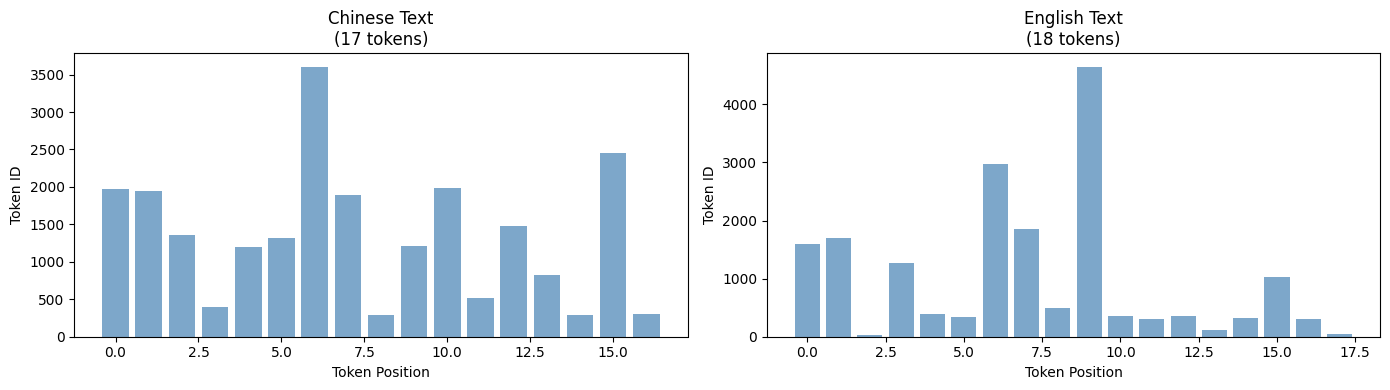

Chinese efficiency: 1.47 chars/token
English efficiency: 3.50 chars/token


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

texts = [
    "你好世界！这是一段中文文本，用于测试分词器的效果。",
    "Hello world! This is an English text for testing the tokenizer."
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (text, ax) in enumerate(zip(texts, axes)):
    tokens = tokenizer.encode(text)
    ax.bar(range(len(tokens)), tokens, color='steelblue', alpha=0.7)
    ax.set_title(f"{'Chinese' if i == 0 else 'English'} Text\n({len(tokens)} tokens)")
    ax.set_xlabel("Token Position")
    ax.set_ylabel("Token ID")
plt.tight_layout()
plt.show()

cn_text = "你好世界！这是一段中文文本，用于测试分词器的效果。"
en_text = "Hello world! This is an English text for testing the tokenizer."
print(f"Chinese efficiency: {len(cn_text)/len(tokenizer.encode(cn_text)):.2f} chars/token")
print(f"English efficiency: {len(en_text)/len(tokenizer.encode(en_text)):.2f} chars/token")

## 📥 Download Datasets

Let's download mini versions of the pretrain and SFT datasets for exploration.
These are subsets of the full training data, suitable for learning and quick experiments.

In [9]:
import os
os.makedirs('/content/minimind-colab/dataset', exist_ok=True)

# Download mini datasets for training
!modelscope download --dataset gongjy/minimind_dataset \
    pretrain_t2t_mini.jsonl sft_t2t_mini.jsonl \
    --local_dir /content/minimind-colab/dataset

print("✅ Datasets downloaded!")


 _   .-')                _ .-') _     ('-.             .-')                              _ (`-.    ('-.
( '.( OO )_             ( (  OO) )  _(  OO)           ( OO ).                           ( (OO  ) _(  OO)
 ,--.   ,--.).-'),-----. \     .'_ (,------.,--.     (_)---\_)   .-----.  .-'),-----.  _.`     \(,------.
 |   `.'   |( OO'  .-.  ',`'--..._) |  .---'|  |.-') /    _ |   '  .--./ ( OO'  .-.  '(__...--'' |  .---'
 |         |/   |  | |  ||  |  \  ' |  |    |  | OO )\  :` `.   |  |('-. /   |  | |  | |  /  | | |  |
 |  |'.'|  |\_) |  |\|  ||  |   ' |(|  '--. |  |`-' | '..`''.) /_) |OO  )\_) |  |\|  | |  |_.' |(|  '--.
 |  |   |  |  \ |  | |  ||  |   / : |  .--'(|  '---.'.-._)   \ ||  |`-'|   \ |  | |  | |  .___.' |  .--'
 |  |   |  |   `'  '-'  '|  '--'  / |  `---.|      | \       /(_'  '--'\    `'  '-'  ' |  |      |  `---.
 `--'   `--'     `-----' `-------'  `------'`------'  `-----'    `-----'      `-----'  `--'      `------'

Processing 2 items:   0% 0.00/2.00 [00:00<?, ?it/s]



## 📈 Dataset Statistics

Let's analyze the structure and length distribution of our datasets.

**Pretrain data**: Raw text documents (Wikipedia, books, web pages)
**SFT data**: Instruction-response pairs in conversation format

=== Pretrain Dataset ===
Samples analyzed: 1000
Avg length: 278 chars
Max length: 1034 chars

Sample:
{
  "text": "给我生成一首有关秋天的诗歌。秋日早晨，清风拂面。\n金色的叶子，似火在燃烧。\n露珠晶莹，如珍珠般美丽。\n秋的气息，弥漫在空气中。\n余音袅袅，如鸟儿的歌唱。\n美丽的秋天，是大自然的馈赠。帮我想一些创意，给即将到来的公司年会准备节目。一些节目比如能否请一位表演者为我们表演一曲钢琴曲，或者请一位小提琴手为大家演奏一首古典曲目。如果想要画面更具有视觉冲击力，可以安排一个魔术师或者杂技演员的表演。另外，也可以设计一些小游戏或者有奖竞猜来增添活动的趣味性，这些小游戏可以和公司的文化、发展历程等相关。请问给我讲一个清净的法则。无为而治是一项清净的法则。即在处理问题时，不要强

=== SFT Dataset ===
Samples analyzed: 1000
Avg length: 1245 chars


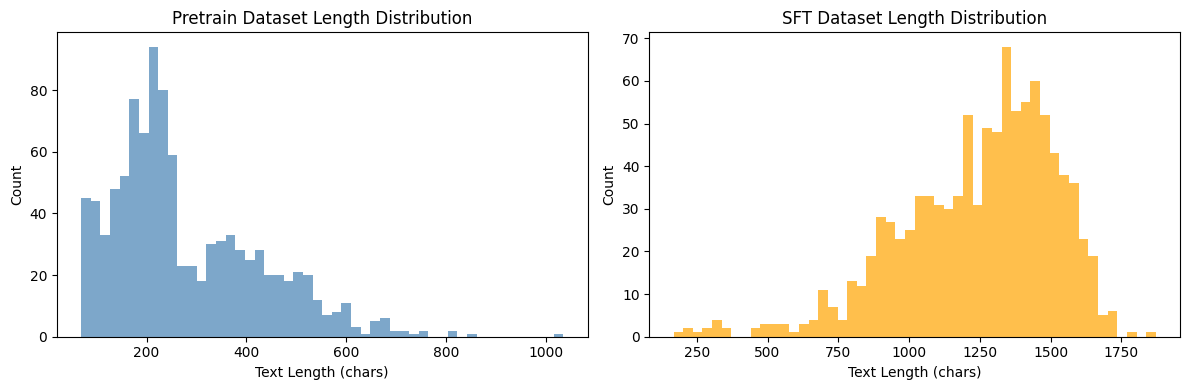

In [10]:
import json
import matplotlib.pyplot as plt

def analyze_jsonl(path, max_samples=1000):
    lengths, samples = [], []
    with open(path) as f:
        for i, line in enumerate(f):
            if i >= max_samples:
                break
            data = json.loads(line.strip())
            text = data.get('text', '') or str(data.get('conversations', ''))
            lengths.append(len(text))
            if i < 3:
                samples.append(data)
    return lengths, samples

pretrain_lengths, pretrain_samples = analyze_jsonl('/content/minimind-colab/dataset/pretrain_t2t_mini.jsonl')
sft_lengths, sft_samples = analyze_jsonl('/content/minimind-colab/dataset/sft_t2t_mini.jsonl')

print("=== Pretrain Dataset ===")
print(f"Samples analyzed: {len(pretrain_lengths)}")
print(f"Avg length: {sum(pretrain_lengths)/len(pretrain_lengths):.0f} chars")
print(f"Max length: {max(pretrain_lengths)} chars")
print(f"\nSample:\n{json.dumps(pretrain_samples[0], ensure_ascii=False, indent=2)[:300]}")

print("\n=== SFT Dataset ===")
print(f"Samples analyzed: {len(sft_lengths)}")
print(f"Avg length: {sum(sft_lengths)/len(sft_lengths):.0f} chars")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pretrain_lengths, bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Pretrain Dataset Length Distribution')
axes[1].hist(sft_lengths, bins=50, color='orange', alpha=0.7)
axes[1].set_title('SFT Dataset Length Distribution')
for ax in axes:
    ax.set_xlabel('Text Length (chars)')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 🔧 Dataset Classes (from `dataset/lm_dataset.py`)

MiniMind provides two main dataset classes:

| Class | Use | Input format |
|-------|-----|-------------|
| `PretrainDataset` | Language modeling | Raw text JSONL |
| `SFTDataset` | Instruction tuning | Conversation JSONL |

Both return `(input_ids, labels)` tensors where labels are shifted input_ids (next-token prediction).

In [12]:
import sys
sys.path.insert(0, '/content/minimind-colab')
import torch
from dataset.lm_dataset import PretrainDataset, SFTDataset
from torch.utils.data import DataLoader

# Load pretrain dataset
pretrain_ds = PretrainDataset(
    '/content/minimind-colab/dataset/pretrain_t2t_mini.jsonl',
    tokenizer,
    max_length=256
)
print(f"Pretrain dataset size: {len(pretrain_ds)}")
x, y = pretrain_ds[0]
print(f"Input shape: {x.shape}, Label shape: {y.shape}")
print(f"First 10 input tokens: {x[:10].tolist()}")
print(f"Decoded input: {tokenizer.decode(x[:20].tolist())!r}")
print(f"\nNote: labels = input_ids shifted by 1 (next-token prediction)")
print(f"Input[0]: {x[0].item():5d} ({tokenizer.decode([x[0].item()])!r})")
print(f"Label[0]: {y[0].item():5d} ({tokenizer.decode([y[0].item()])!r} if y[0].item() >= 0 else 'IGNORE')")

# Load SFT dataset
sft_ds = SFTDataset(
    '/content/minimind-colab/dataset/sft_t2t_mini.jsonl',
    tokenizer,
    max_length=256
)
print(f"\nSFT dataset size: {len(sft_ds)}")
x_sft, y_sft = sft_ds[0]
print(f"SFT Input shape: {x_sft.shape}, Label shape: {y_sft.shape}")
print(f"Note: In SFT, prompt tokens have label=-100 (ignored in loss)")
non_ignored = (y_sft != -100).sum().item()
print(f"Non-ignored label tokens: {non_ignored}/{len(y_sft)} ({100*non_ignored/len(y_sft):.1f}%)")

Generating train split: 0 examples [00:00, ? examples/s]

Pretrain dataset size: 1270238
Input shape: torch.Size([256]), Label shape: torch.Size([256])
First 10 input tokens: [1, 3530, 1424, 349, 1408, 5273, 3580, 993, 296, 5140]
Decoded input: '<|im_start|>给我生成一首有关秋天的诗歌。秋日早晨，清风拂'

Note: labels = input_ids shifted by 1 (next-token prediction)
Input[0]:     1 ('<|im_start|>')
Label[0]:     1 ('<|im_start|>' if y[0].item() >= 0 else 'IGNORE')


Generating train split: 0 examples [00:00, ? examples/s]


SFT dataset size: 905718
SFT Input shape: torch.Size([256]), Label shape: torch.Size([256])
Note: In SFT, prompt tokens have label=-100 (ignored in loss)
Non-ignored label tokens: 213/256 (83.2%)


## 📝 Student Exercise

1. **Compare tokenizer efficiency**: How many tokens does MiniMind's tokenizer use vs character count for:
   - A complex Chinese sentence
   - Python code
   - Mathematical equations

2. **Examine the SFT data format**: Look at `sft_t2t_mini.jsonl` and understand why prompt tokens get `label=-100`

3. **DataLoader experiment**: Create a DataLoader with `batch_size=4` and examine a batch:
```python
loader = DataLoader(pretrain_ds, batch_size=4, shuffle=True)
batch_x, batch_y = next(iter(loader))
print(f"Batch shape: {batch_x.shape}")  # [4, max_length]
```

## 💡 Discussion Questions

1. **Why 6,400 vocab vs 151,643 in Qwen2?**
   - Smaller vocab: Fewer embedding parameters (6400 × 768 = 4.9M vs 151643 × 768 = 116M)
   - But: More tokens needed to represent the same text (less efficient encoding)
   - Tradeoff: MiniMind optimizes for small model size at the cost of encoding efficiency

2. **Why do we mask prompt tokens with -100 in SFT?**
   - We only want the model to learn how to generate *responses*, not repeat the prompt
   - PyTorch's `CrossEntropyLoss` ignores positions where label is -100

3. **What is the difference between pretrain and SFT data?**
   - Pretrain: "The capital of France is Paris." → model learns world knowledge
   - SFT: "Q: What is the capital of France? A: Paris." → model learns to follow instructions